# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline



In [2]:
# Load the Iris dataset
train = pd.read_csv('Iris.csv')

In [24]:
! pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 seaborn==0.13.2

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.11.4-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scipy-1.11.4-cp311-cp311-win_amd64.whl (44.1 MB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.2 MB 4.2 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.2 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.2 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.2 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.2 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.2 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.2 MB 1.9 MB/s eta 0:00:05

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
feature-engine 1.9.4 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [3]:
train = pd.read_csv('Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


C:\Users\Sofyan Didik\AppData\Local\Temp\ipykernel_2996\34752576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

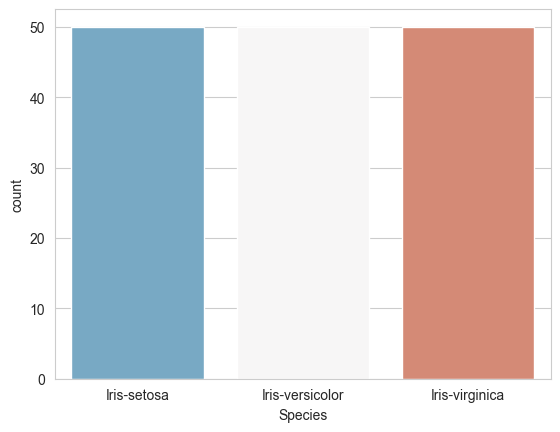

In [7]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='RdBu_r')

C:\Users\Sofyan Didik\AppData\Local\Temp\ipykernel_2996\2160609501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

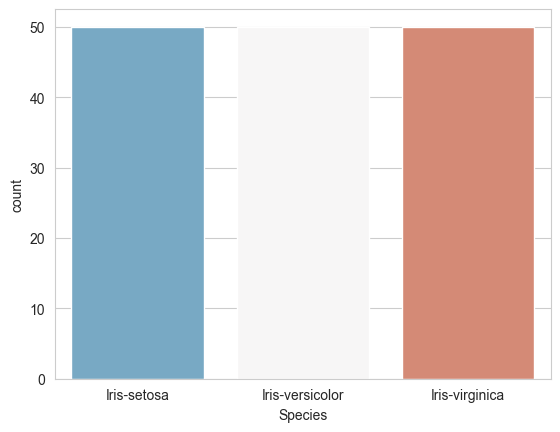

In [10]:
# Survivablity vs sex
sns.set_style('whitegrid')
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='RdBu_r')

C:\Users\Sofyan Didik\AppData\Local\Temp\ipykernel_2996\2632179357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='rainbow')


<Axes: xlabel='Species', ylabel='count'>

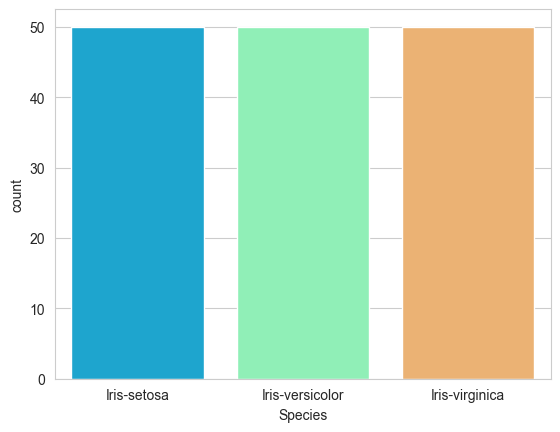

In [12]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
# Species count
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='rainbow')

Text(0.5, 1.0, 'Persentase penumpang yang selamat berdasarkan kelas')

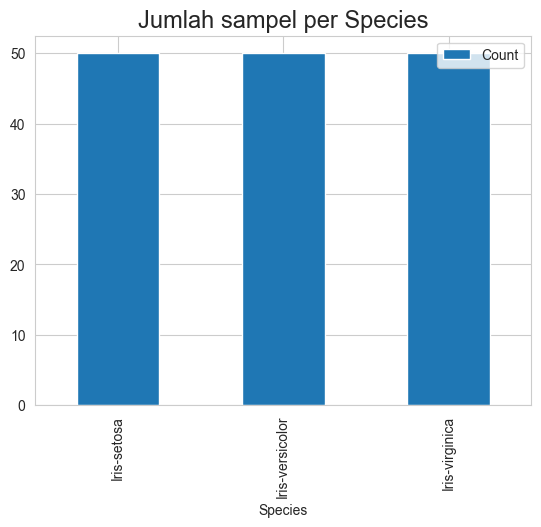

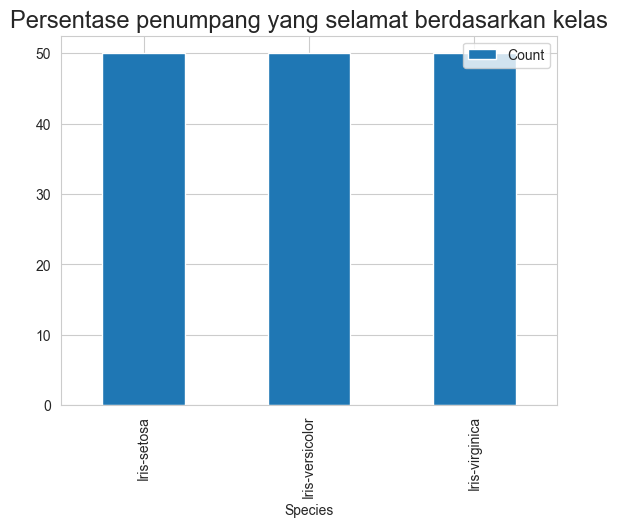

In [16]:
train = pd.read_csv('Iris.csv')
train = pd.read_csv('Iris.csv')
f_class_survived = pd.DataFrame(train['Species'].value_counts()).reset_index()
f_class_survived.columns = ['Species', 'Count']
f_class_survived
f_class_survived.plot.bar(x='Species', y='Count')
plt.title("Jumlah sampel per Species", fontsize=17)
f_class_survived
f_class_survived.plot.bar(x='Species', y='Count')
plt.title("Persentase penumpang yang selamat berdasarkan kelas",fontsize=17)

C:\Users\Sofyan Didik\AppData\Local\Temp\ipykernel_2996\2681166740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='rainbow')


<Axes: xlabel='Species', ylabel='count'>

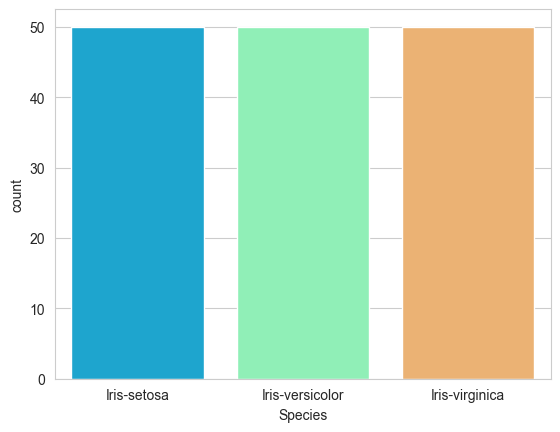

In [18]:
# Survived vs Sibling and Spouses
sns.set_style('whitegrid')
# Species count
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='rainbow')

<Axes: title={'center': 'Histogram Sepal Length'}, xlabel='Sepal Length', ylabel='Count'>

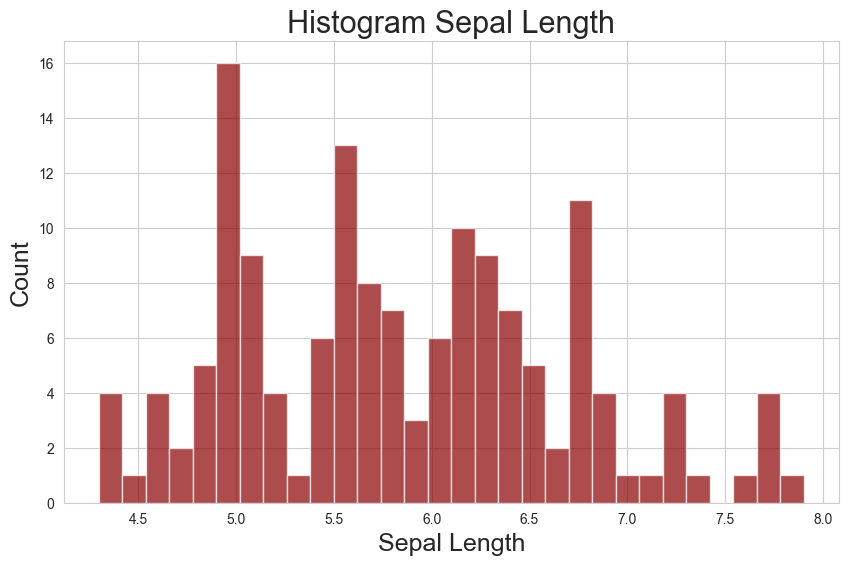

In [23]:
# Cek distribusi dari umur
plt.xlabel("Usia penumpang",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia penumpang",fontsize=22)
plt.xlabel("Sepal Length", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Sepal Length", fontsize=22)
train['SepalLengthCm'].hist(bins=30, color='darkred', alpha=0.7, figsize=(10,6))

C:\Users\Sofyan Didik\AppData\Local\Temp\ipykernel_2996\1013986056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter')


<Axes: xlabel='Passenger Class', ylabel='Age'>

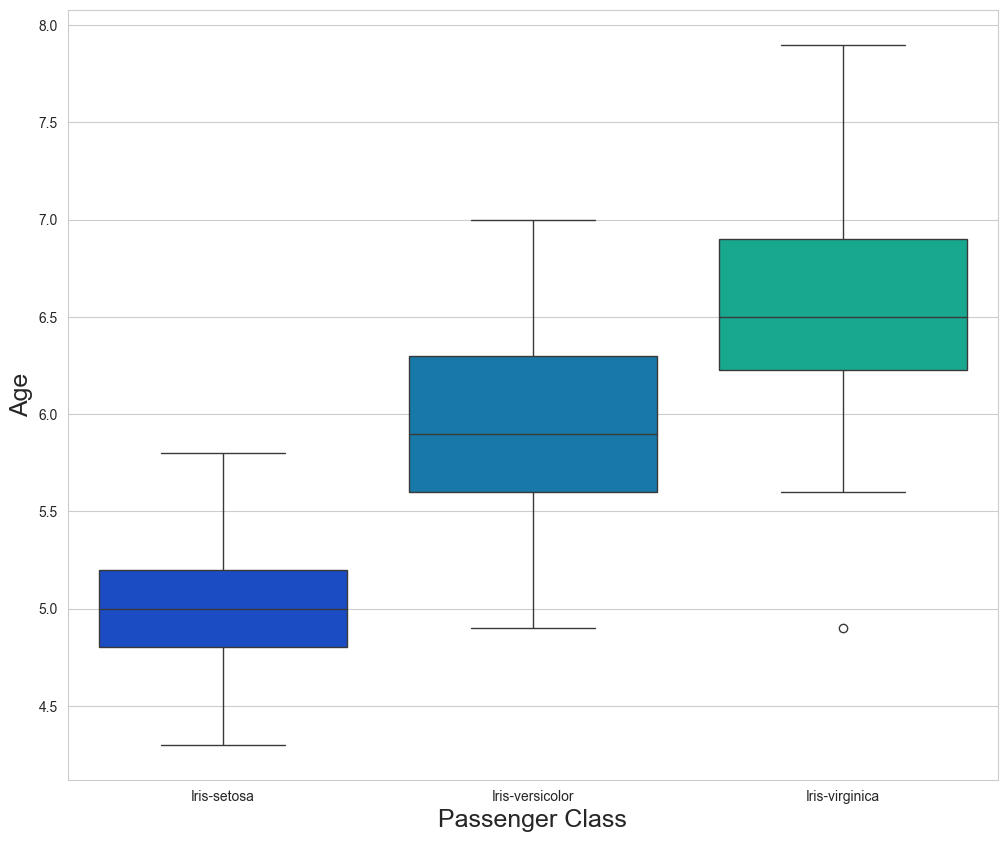

In [32]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Passenger Class",fontsize=18)
plt.ylabel("Age",fontsize=18)
sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter')

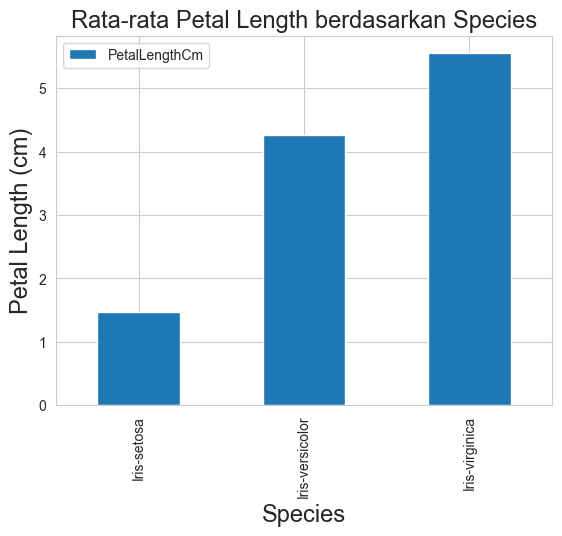

In [33]:
f_class = train.groupby('Species')['PetalLengthCm'].mean()
f_class = pd.DataFrame(f_class)

f_class.plot.bar(y='PetalLengthCm')

plt.title("Rata-rata Petal Length berdasarkan Species", fontsize=17)
plt.ylabel("Petal Length (cm)", fontsize=17)
plt.xlabel("Species", fontsize=17)
plt.show()

### Fitur Engineering

In [35]:
f_class = train.groupby('Species')['SepalLengthCm'].mean()
a = list(f_class)

def impute_sepal(cols):
    sepal = cols[0]
    species = cols[1]

    if pd.isnull(sepal):

        if species == 'Iris-setosa':
            return a[0]

        elif species == 'Iris-versicolor':
            return a[1]

        else:
            return a[2]

    else:
        return sepal

In [38]:
def impute_sepal(cols):
    sepal = cols['SepalLengthCm']
    species = cols['Species']

    if pd.isnull(sepal):
        if species == 'Iris-setosa':
            return a[0]
        elif species == 'Iris-versicolor':
            return a[1]
        else:
            return a[2]
    else:
        return sepal

train['SepalLengthCm'] = train[['SepalLengthCm', 'Species']].apply(impute_sepal, axis=1)

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

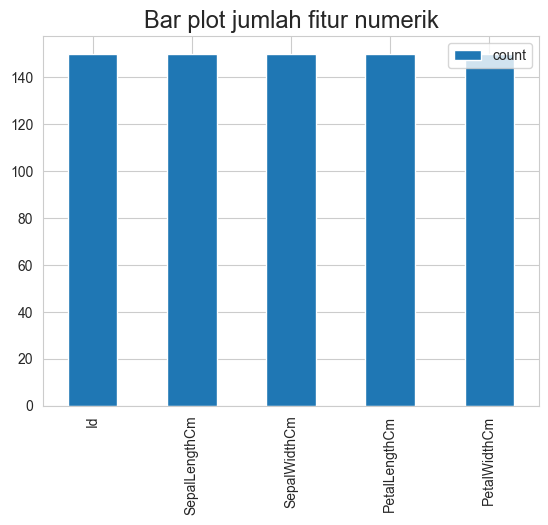

In [39]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [41]:
# drop cabin karena memiliki banyak null value (>50%)
if 'Cabin' in train.columns:
    train.drop('Cabin', axis=1, inplace=True)
train.dropna(inplace=True)
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [43]:
# Drop semua kolom yang tidak penting
train.drop(['Id'], axis=1, inplace=True)
train.head()
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])
train.head()
le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])
if 'Embarked' in train.columns:
    train['Embarked'] = le.fit_transform(train['Embarked'])
train.head()
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Training

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Species', axis=1),
    train['Species'],
    test_size=0.30,
    random_state=42
)

In [49]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (105, 4)
Test shape: (45, 4)


# **KNN**

In [50]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [51]:
y_pred = clf1.predict(X_test)

### Evaluation

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [53]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors

In [56]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [57]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [58]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [60]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi apakah penumpang ini selamat atau tidak
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = best_model.predict(new_data)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 0
Prediksi (0 = Tidak Selamat, 1 = Selamat): 0


c:\Program Files\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
